In [39]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path
import monai
import shutil

In [2]:
sitk.ProcessObject.SetGlobalWarningDisplay(False)  

In [15]:
PROJECT_ROOT=Path("/home/jovyan/thesis_project")
PROJECT_FM_THESIS= PROJECT_ROOT / "FM_thesis"

DATA_ROOT = Path("/home/jovyan/thesis_project/datasets/mama_mia")

In [33]:
suffix= "1226"

image_file=DATA_ROOT / "images" / f"ISPY1_{suffix}" / f"ISPY1_{suffix}_0000.nii.gz"
image_gt=DATA_ROOT / "segmentations" / "expert" / f"ISPY1_{suffix}.nii.gz"
image_gt_automatic= DATA_ROOT / "segmentations" / "automatic" / f"ISPY1_{suffix}.nii.gz"


image=sitk.ReadImage(image_file)
image_gt=sitk.ReadImage(image_gt)
image_gt_automatic=sitk.ReadImage(image_gt_automatic)

image_array = sitk.GetArrayFromImage(image)
image_gt_array = sitk.GetArrayFromImage(image_gt)
image_gt_automatic_array = sitk.GetArrayFromImage(image_gt_automatic)

In [20]:
image_gt_array.shape

(60, 256, 256)

In [40]:
images_folder= DATA_ROOT / "images"
gt_dir= DATA_ROOT / "segmentations" / "expert"
output_dir= DATA_ROOT / "extracted_slices"
output_dir.mkdir(parents=True, exist_ok=True)


for f in images_folder.iterdir():
    name = f.name

    if "ISPY1" not in name:
        continue

    volume = f / f"{name}_0001.nii.gz"
    gt = gt_dir / f"{name}.nii.gz"

    image = sitk.ReadImage(str(volume))
    image_gt = sitk.ReadImage(str(gt))

    image_array = sitk.GetArrayFromImage(image)
    image_gt_array = sitk.GetArrayFromImage(image_gt)

    idx = image_gt_array.sum(axis=(1, 2)).argmax()

    best_slice = image_array[idx]
    best_slice_gt = image_gt_array[idx]

    patient_dir = output_dir / name
    patient_dir.mkdir(exist_ok=True)
    
    np.savez_compressed(patient_dir / "image.npz", image=best_slice)
    np.savez_compressed(patient_dir / "mask.npz", mask=best_slice_gt)

    
        


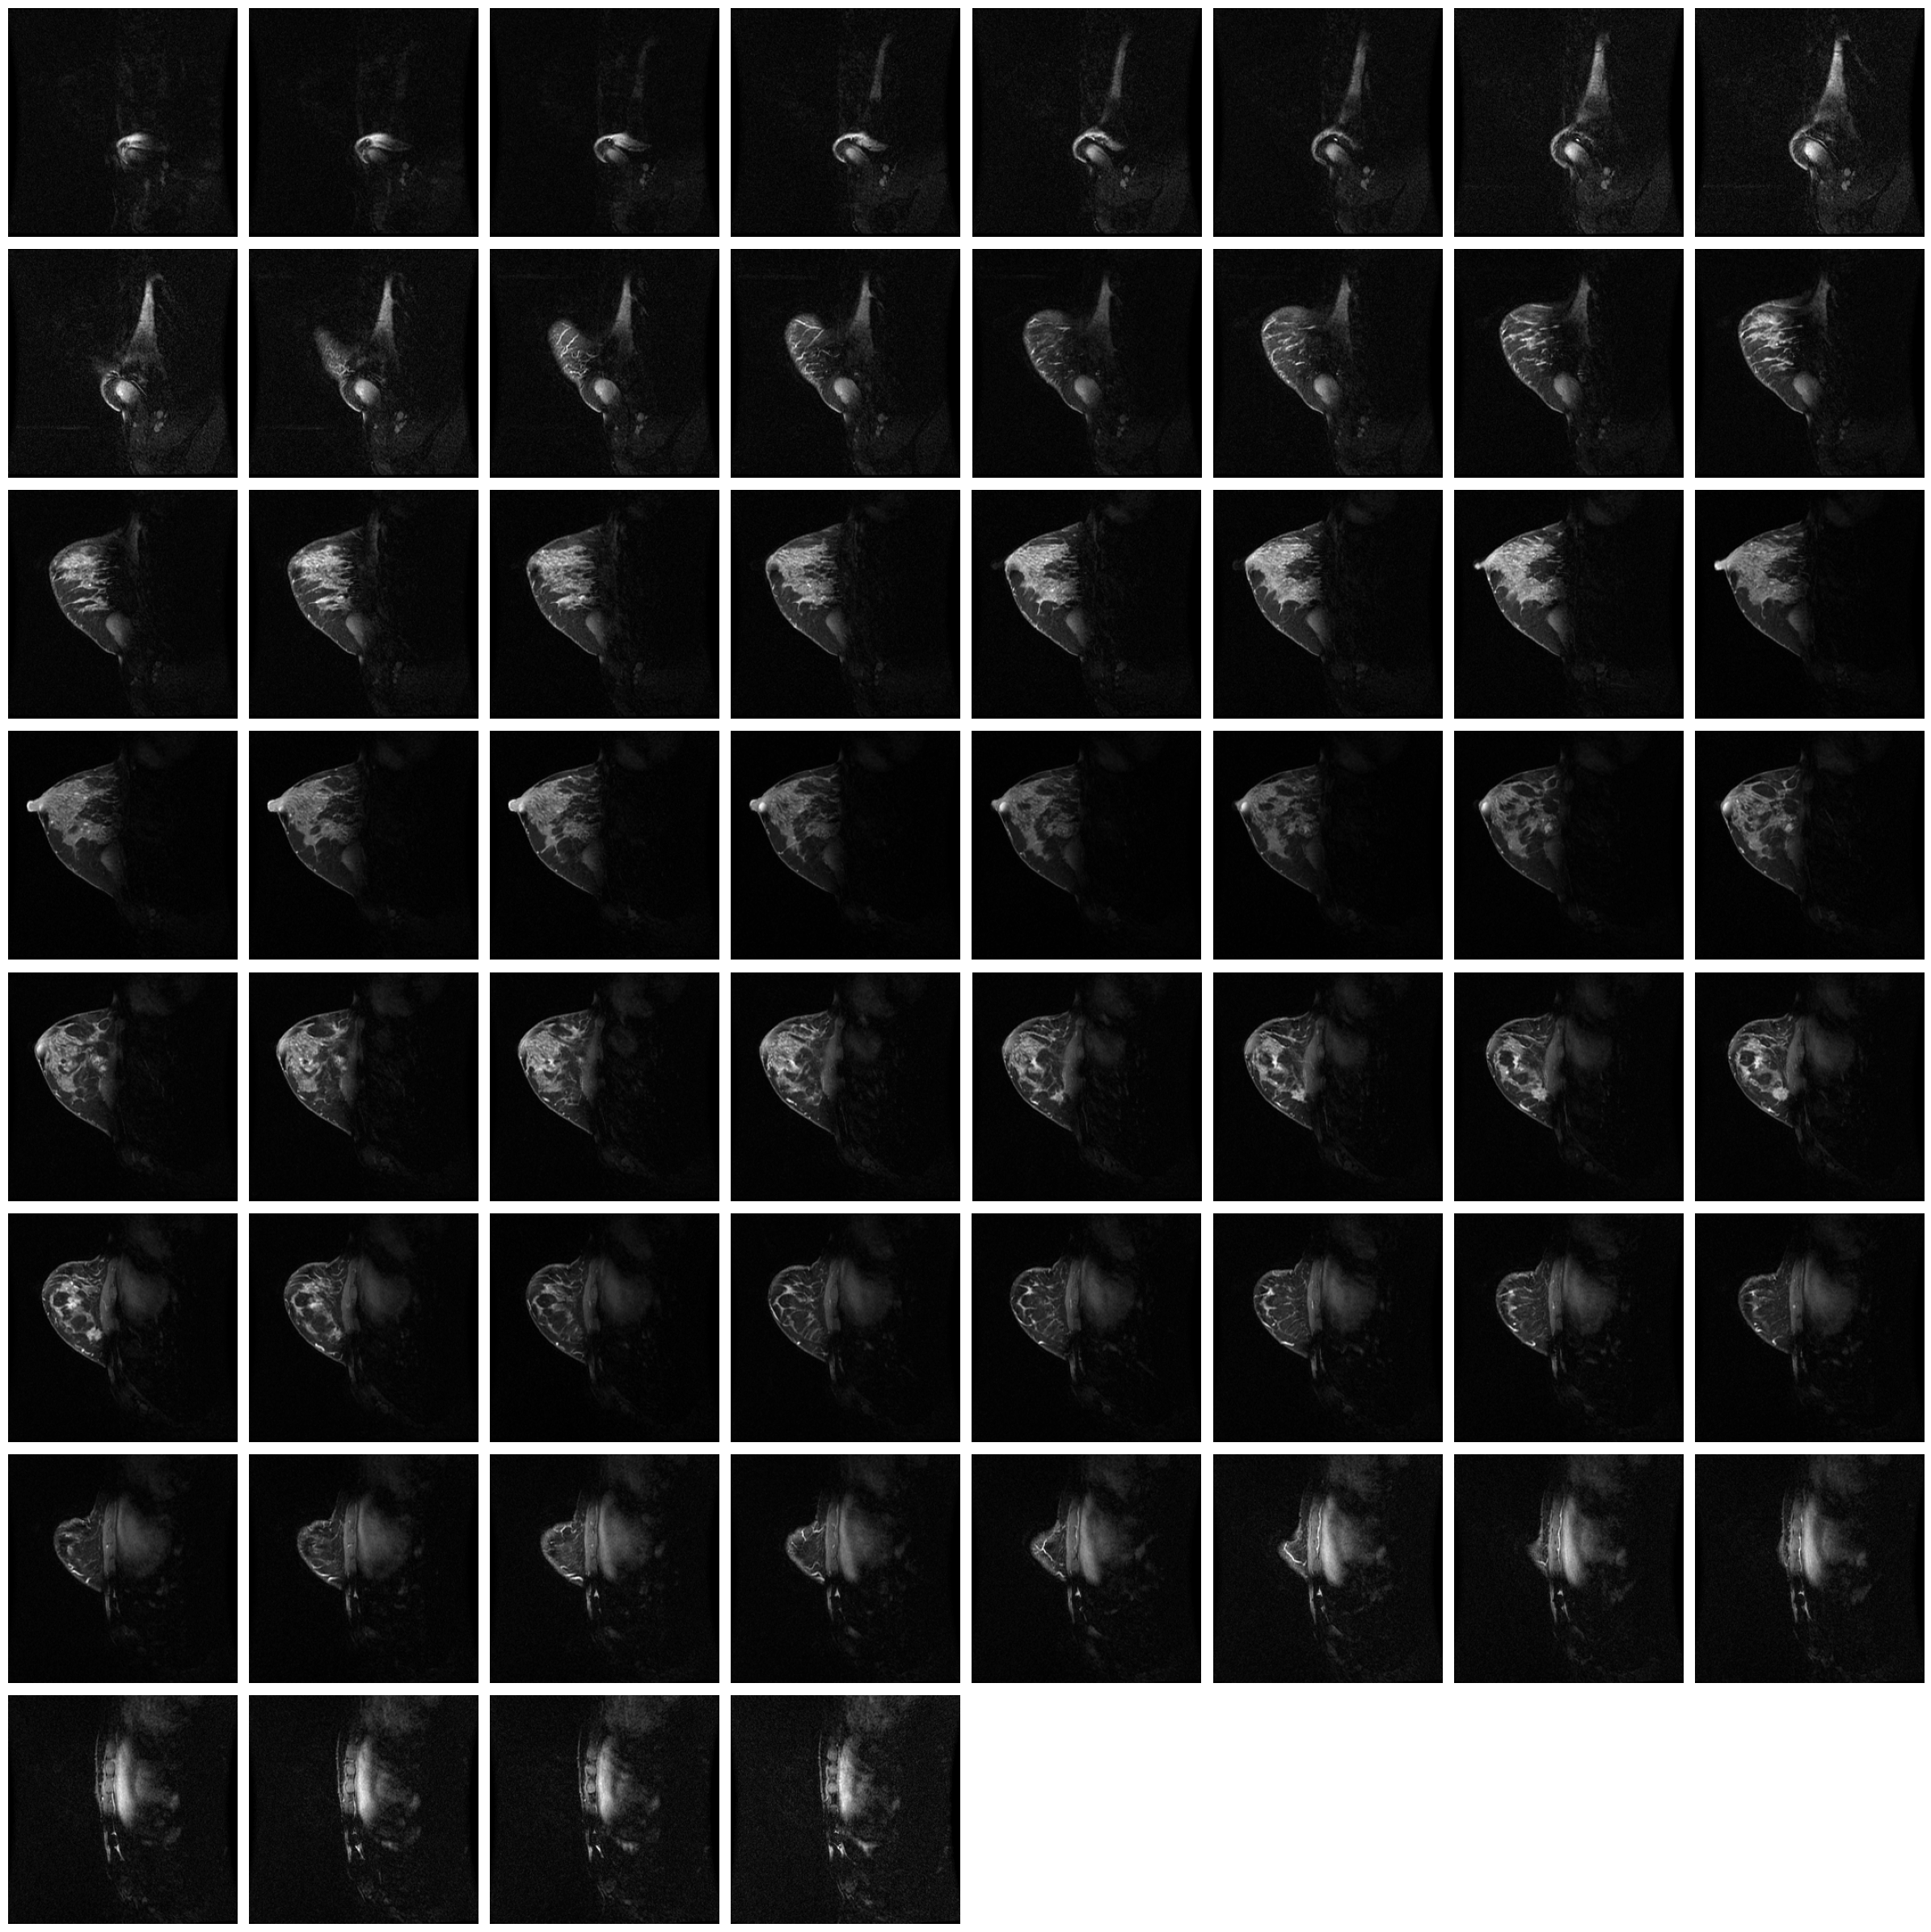

In [31]:
from IPython.display import clear_output
import torch
import math

x=image_array

n_imgs = x.shape[0]

n_cols = math.ceil(math.sqrt(n_imgs))
n_rows = math.ceil(n_imgs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
axes = axes.flatten()

clear_output(wait=True)


for i in range(n_imgs):
    img = x[i]
    axes[i].imshow(img, cmap="gray")
    axes[i].axis("off")

for j in range(n_imgs, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
plt.pause(0.5)